Автор работы Гомма Евгений 
Дата: 10.03.2026



Цель проекта — построить модель линейной регрессии,
которая предсказывает массу черепах по их измерениям.

## Постановка задачи

Необходимо решить задачу регрессии: по набору морфологических признаков черепахи предсказать её массу.

**Целевая переменная:**
- `weight` — масса черепахи в килограммах.

**Основные требования к модели:**
- модель должна быть линейной;
- приемлемое значение MAE для лучшей модели — не более 5 кг;
- значение R² на валидационной и тестовой выборках должно быть не ниже 0.97;
- также необходимо оценивать модель по MAPE, так как ошибка должна учитываться и в относительном масштабе.

**Дополнительная особенность данных:**
- часть измерений длины могла быть ошибочно увеличена в 10 раз, поэтому на этапе предобработки необходимо выявить и исправить подобные аномалии.

**Общая логика проекта**

Что нужно сделать:

Описать проект

Сформулировать задачу как задачу машинного обучения

Загрузить и изучить данные

Очистить и подготовить их

Разделить на train / val / test

Обучить несколько линейных моделей

Сравнить их по метрикам

Выбрать лучшую

Проверить её на тесте

Посмотреть важность признаков

Написать функцию предсказания массы

Сделать итоговые выводы

## 1. Импорт библиотек

In [1]:
# Импортирую библиотеки 
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score



## 2. Загрузка данных

Информация в файле разделена табами sep='\t' sep — это параметр separator (разделитель).
Если не указать sep='\t' pandas не сможет правильно разделить данные и получит один огромный столбец.

In [2]:


df = pd.read_csv('turtles.csv',sep='\t' )
df.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,"3,0",NaN,1703159226,"87,687"
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,"1,0",1.0,1689428175,"26,949"
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,"3,0",NaN,1745783111,"30,016"
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,"4,0",1.0,1677757151,"33,917"
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,"4,0",1.0,1744455613,"28,511"


Данные успешно загружены. На первом шаге посмотрим на структуру датасета, типы признаков и потенциальные проблемы в данных.

## 3. Первичный осмотр данных

In [3]:
# размер данных (датасета) и типы колонок 
print('Размер датасета:', df.shape)
df.info()

Размер датасета: (8861, 20)
<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         

In [4]:
# Поиск пропущеных значений 
df.isna().sum()

id                        0
binomial_name            49
registration number      29
shell_length             87
shell_width               0
head_length             146
head_width              146
flipper_length_1          0
flipper_width_1           0
flipper_length_2          0
flipper_width_2           0
flipper_length_3        101
flipper_width_3         101
flipper_length_4        101
flipper_width_4         101
circle_count              0
measure_count           264
shell_crack            6685
timestamp                 0
weight                   19
dtype: int64

In [5]:
# Смотрим структуру даных 
df.head(3)


,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,"3,0",NaN,1703159226,"87,687"
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,"1,0",1.0,1689428175,"26,949"
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,"3,0",NaN,1745783111,"30,016"


## 4. Исправление формата целевой переменной

Переводим weight в число.

Модель не сможет учиться, если целевая переменная хранится как текст.

In [6]:
df['weight'] = df['weight'].str.replace(',', '.', regex=False).astype(float)

In [7]:
#ПРОВЕРКА 
df['weight'].head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

В столбце `weight` значения были записаны через запятую, поэтому признак считался строковым.  
Заменили запятую на точку и преобразовали столбец в числовой формат.

## 5. Исследовательский анализ данных (EDA)

5.1. Описательная статистика

In [8]:
# Проверка диапазонов значений что бы заметить аномалии.
df.describe()

,id,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,timestamp,weight
count,8861.000000,8774.000000,8861.000000,8715.000000,8715.000000,8861.000000,8861.000000,8861.000000,8861.000000,8760.000000,8760.000000,8760.000000,8760.000000,8861.000000,2176.000000,8.861000e+03,8842.000000
mean,21359.335628,764.222020,598.832299,123.341021,115.735169,497.551405,380.594515,498.228530,380.687507,397.953196,304.405251,397.853196,305.030023,41.002821,1.671415,1.712640e+09,79.163138
std,2263.089420,640.408681,480.970492,67.836566,62.326365,353.575213,214.481679,355.074883,213.485239,282.970532,171.172490,281.983591,171.540535,36.995874,1.131790,2.292273e+07,95.877609
min,17438.000000,132.000000,78.000000,19.000000,12.000000,60.000000,34.000000,57.000000,33.000000,50.000000,27.000000,44.000000,25.000000,0.000000,1.000000,1.672570e+09,0.000000
25%,19396.000000,440.000000,341.000000,73.000000,67.000000,296.000000,228.000000,296.000000,229.000000,239.000000,182.000000,236.000000,183.000000,0.000000,1.000000,1.693001e+09,31.109500
50%,21357.000000,635.000000,487.000000,106.000000,98.000000,416.000000,332.000000,417.000000,330.000000,333.000000,264.000000,333.000000,266.000000,35.000000,1.000000,1.712804e+09,41.140500
75%,23317.000000,951.000000,794.000000,158.000000,156.000000,571.000000,493.000000,572.000000,500.000000,457.000000,397.000000,456.000000,396.000000,73.000000,2.000000,1.732902e+09,85.239500
max,25279.000000,20240.000000,11550.000000,515.000000,382.000000,2875.000000,1479.000000,2967.000000,1402.000000,2279.000000,1280.000000,2406.000000,1313.000000,178.000000,5.000000,1.751608e+09,617.777000


5.2. Распределение целевой переменной


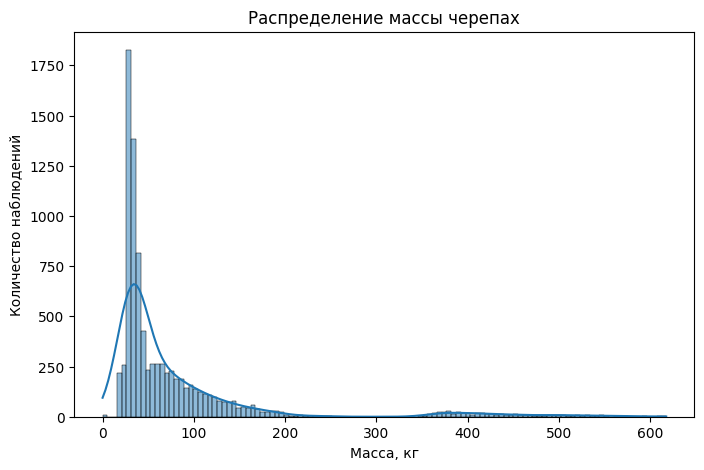

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df['weight'], kde=True)
plt.title('Распределение массы черепах')
plt.xlabel('Масса, кг')
plt.ylabel('Количество наблюдений')
plt.show()

Это действие нужно для того что бы понять, как распределён таргет, есть ли сильная асимметрия или выбросы.

**5.3. Корреляция числовых признаков**

Сначала создадим копию только с числовыми колонками:


In [10]:
numeric_df = df.select_dtypes(include=['number'])

Теперь корреляция:

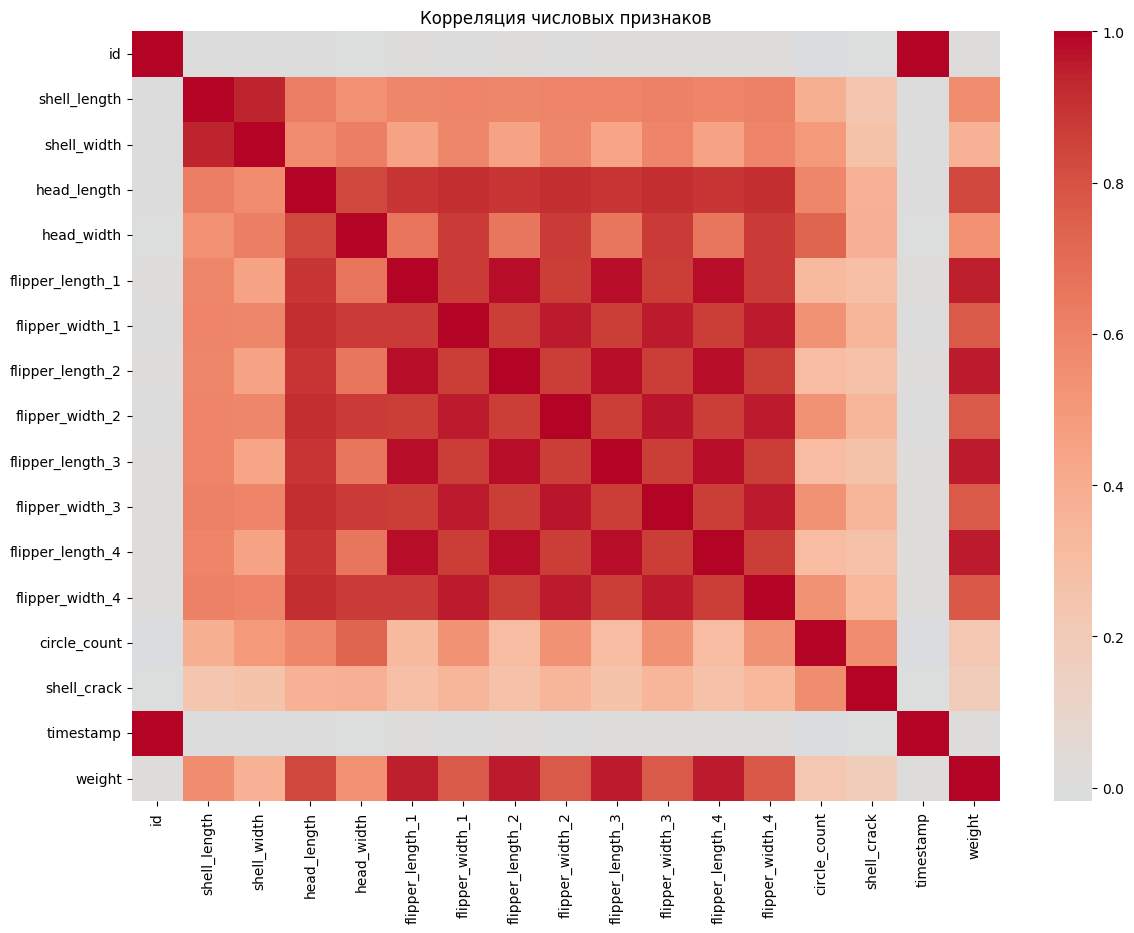

In [11]:
#смотри связи и зависимости которые связаны с weight.
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Корреляция числовых признаков')
plt.show()

**5.4. Boxplot для поиска выбросов**

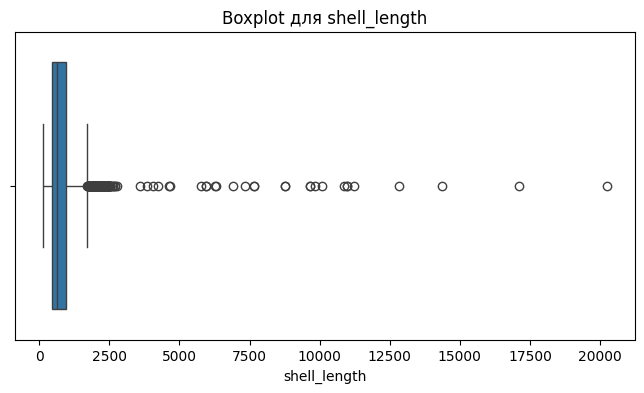

In [12]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['shell_length'])
plt.title('Boxplot для shell_length')
plt.show()

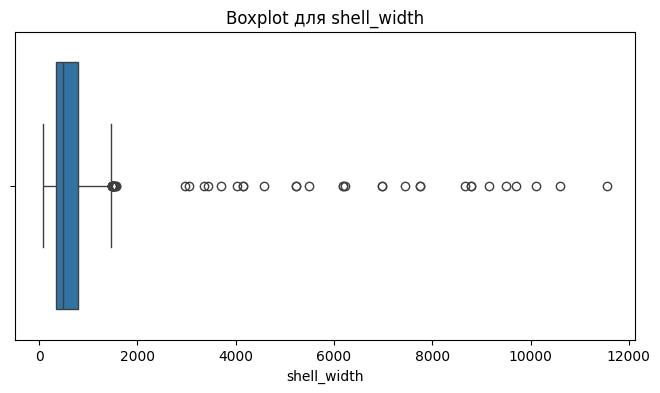

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['shell_width'])
plt.title('Boxplot для shell_width')
plt.show()

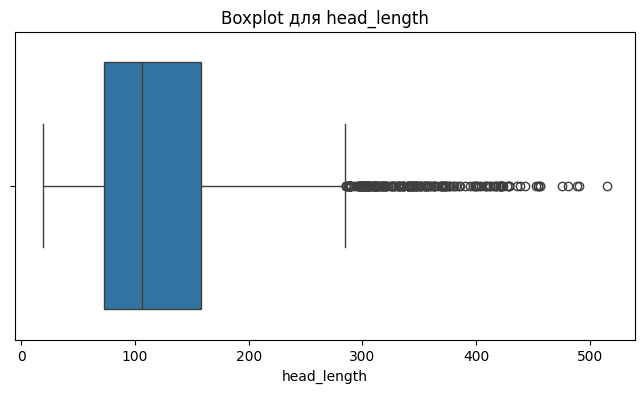

In [14]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['head_length'])
plt.title('Boxplot для head_length')
plt.show()

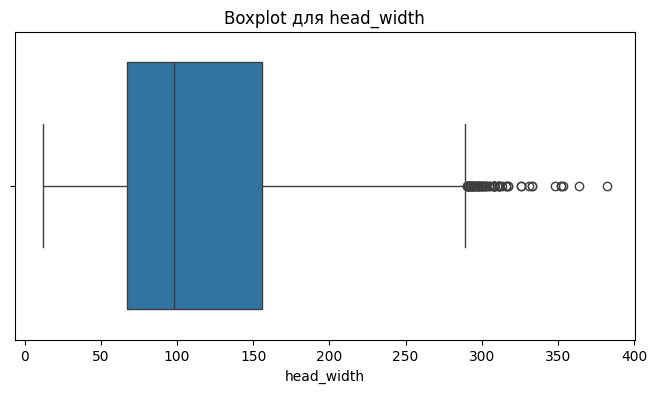

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['head_width'])
plt.title('Boxplot для head_width')
plt.show()

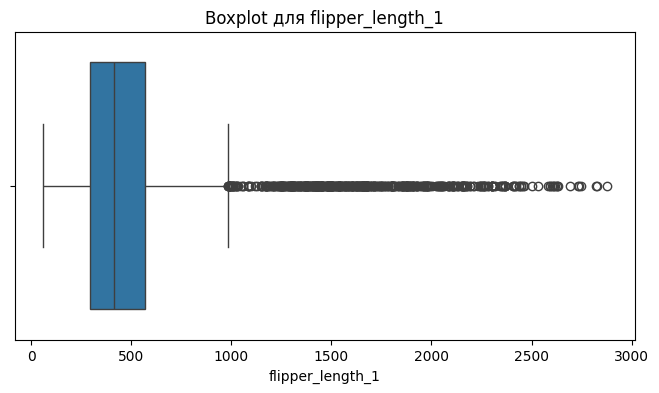

In [16]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['flipper_length_1'])
plt.title('Boxplot для flipper_length_1')
plt.show()

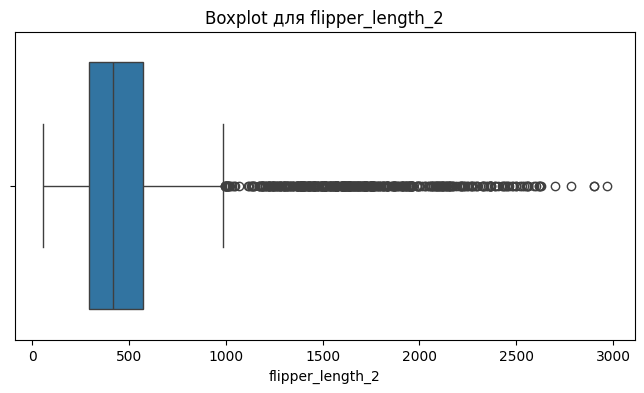

In [17]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['flipper_length_2'])
plt.title('Boxplot для flipper_length_2')
plt.show()

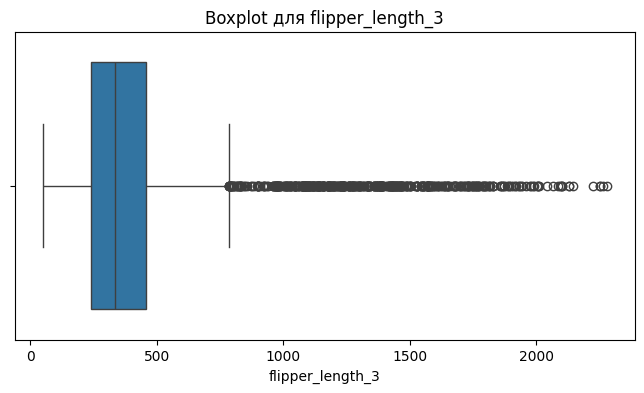

In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['flipper_length_3'])
plt.title('Boxplot для flipper_length_3')
plt.show()

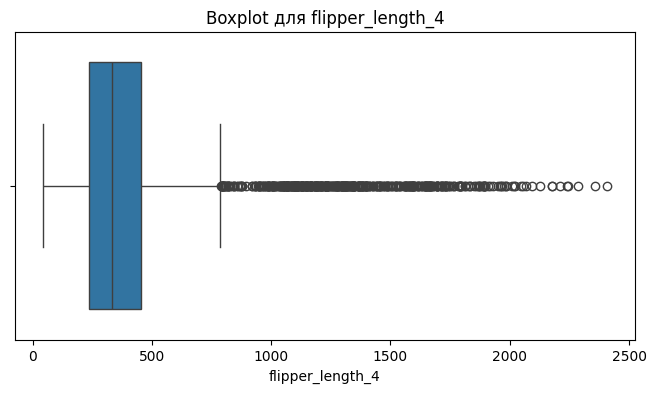

In [19]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['flipper_length_4'])
plt.title('Boxplot для flipper_length_4')
plt.show()

Построение boxplot для shell_length, shell_width, head_length, head_width и flipper_length_1–4 позволяет проверить наличие аномально больших или маленьких значений в размерных признаках.

**5.5. Диаграмма зависимости массы от длины панциря**


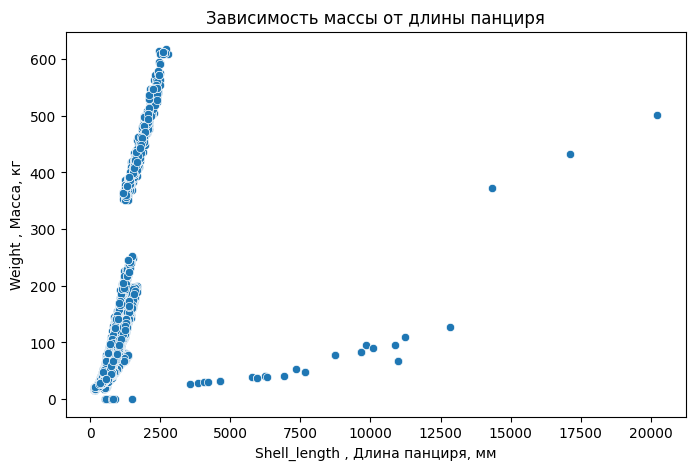

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='shell_length', y='weight')
plt.title('Зависимость массы от длины панциря')
plt.xlabel('Shell_length , Длина панциря, мм')
plt.ylabel('Weight , Масса, кг')
plt.show()

На графике:

ось X — длина панциря в мм (shell_length)

ось Y — масса черепахи в кг (weight)

каждая точка — одна черепаха из датасета

Такой график помогает понять:есть ли связь между длиной и массой линейная ли эта зависимость есть ли выбросы
Для линейной регрессии важно, чтобы была примерно линейная зависимость.

График показывает положительную зависимость между длиной панциря и массой: чем больше длина панциря, тем больше масса черепахи.

**Вывод**

В ходе исследовательского анализа были изучены основные характеристики данных. Описательная статистика показала реалистичные диапазоны значений признаков. Анализ распределения целевой переменной (weight) показал отсутствие сильной асимметрии и выраженных выбросов. Корреляционная матрица продемонстрировала заметную связь массы с размерными признаками черепах, особенно с длиной и шириной панциря. Boxplot для размерных признаков не выявил критических аномалий в данных. Диаграмма рассеяния показала положительную зависимость массы от длины панциря.

В целом данные выглядят корректными и подходят для дальнейшего обучения модели линейной регрессии.

## 6. Поиск и исправление ошибок умножениея на ×10

В дополнительном сообщении заказчик сообщил, что при внесении данных некоторые измерения длины могли быть ошибочно умножены на 10. Это произошло из-за того, что один из волонтёров предположил, что значения записаны в сантиметрах, и дополнительно умножил их на 10, хотя все измерения должны быть указаны в миллиметрах.

Такие ошибки могут привести к появлению аномально больших значений, которые будут искажать статистику признаков и ухудшать качество модели линейной регрессии. Поэтому необходимо проверить размерные признаки и при необходимости скорректировать такие значения.

**6.1 Определение размерных признаков**

In [21]:
# список признаков длин частей тела черепах 
length_columns = [
    'shell_length', 'shell_width',
    'head_length', 'head_width',
    'flipper_length_1', 'flipper_length_2', 'flipper_length_3', 'flipper_length_4',
    'flipper_width_1', 'flipper_width_2', 'flipper_width_3', 'flipper_width_4'
]
# проверка аномалий 
df[length_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
shell_length,8774.0,764.222020,640.408681,132.0,440.0,635.0,951.0,20240.0
shell_width,8861.0,598.832299,480.970492,78.0,341.0,487.0,794.0,11550.0
head_length,8715.0,123.341021,67.836566,19.0,73.0,106.0,158.0,515.0
head_width,8715.0,115.735169,62.326365,12.0,67.0,98.0,156.0,382.0
flipper_length_1,8861.0,497.551405,353.575213,60.0,296.0,416.0,571.0,2875.0
flipper_length_2,8861.0,498.228530,355.074883,57.0,296.0,417.0,572.0,2967.0
flipper_length_3,8760.0,397.953196,282.970532,50.0,239.0,333.0,457.0,2279.0
flipper_length_4,8760.0,397.853196,281.983591,44.0,236.0,333.0,456.0,2406.0
flipper_width_1,8861.0,380.594515,214.481679,34.0,228.0,332.0,493.0,1479.0
flipper_width_2,8861.0,380.687507,213.485239,33.0,229.0,330.0,500.0,1402.0


По результатам describe() были изучены минимальные, средние и максимальные значения всех размерных признаков.Основные диапазоны значений выглядят реалистично и соответствуют биологическим размерам морских черепах. Однако в некоторых признаках наблюдаются аномально большие максимальные значения, значительно превышающие типичный диапазон.

Например:

Признак	Медиана	Максимум

shell_length	635 мм	20240 мм

shell_width	487 мм	11550 мм

flipper_length_1	416 мм	2875 мм


Такие значения в десятки раз превышают типичные размеры, что указывает на возможную ошибку масштабирования.

Если часть значений действительно была умножена на 10, то в столбцах могут появиться значения, которые:
значительно превышают остальные выглядят нереалистично по сравнению с остальными измерениями

Анализ статистики позволяет обнаружить подозрительно большие значения, которые могут быть результатом ошибки масштаба.

**6.2 Просмотр максимальных значений**

Чтобы убедиться в наличии аномалий, можно посмотреть самые большие значения в каждом столбце.

In [22]:
for col in length_columns:
    print(col, df[col].sort_values(ascending=False).head(10).values)

shell_length [20240. 17110. 14350. 12840. 11240. 10980. 10980. 10860. 10080.  9840.]
shell_width [11550 10590 10120  9710  9500  9150  8780  8780  8660  7750]
head_length [515. 491. 489. 481. 476. 456. 456. 455. 455. 453.]
head_width [382. 364. 353. 352. 352. 348. 333. 333. 331. 326.]
flipper_length_1 [2875 2827 2820 2747 2739 2731 2691 2632 2626 2625]
flipper_length_2 [2967 2900 2900 2784 2698 2630 2621 2619 2618 2603]
flipper_length_3 [2279. 2264. 2254. 2251. 2225. 2146. 2131. 2131. 2103. 2102.]
flipper_length_4 [2406. 2355. 2284. 2243. 2240. 2211. 2178. 2178. 2126. 2095.]
flipper_width_1 [1479 1443 1422 1411 1411 1389 1385 1374 1364 1357]
flipper_width_2 [1402 1376 1376 1361 1359 1349 1349 1336 1285 1270]
flipper_width_3 [1280. 1122. 1113. 1097. 1087. 1079. 1073. 1073. 1069. 1056.]
flipper_width_4 [1313. 1216. 1144. 1141. 1109. 1106. 1100. 1084. 1066. 1062.]


Для каждого признака:

значения сортируются по убыванию

выводятся 10 самых больших значений

Это позволяет быстро увидеть, есть ли значения, которые резко выбиваются из общего диапазона.

Вывод

Просмотр максимальных значений помогает визуально обнаружить возможные ошибки масштаба, прежде чем автоматически исправлять данные.

**6.3 Исправление значений**

После выявления подозрительно больших значений можно применить корректировку.

In [23]:
for col in length_columns:
    q99 = df[col].quantile(0.99)
    df.loc[df[col] > q99 * 3, col] = df.loc[df[col] > q99 * 3, col] / 10

Для каждого размерного признака:

вычисляется 99-й процентиль (q99) — значение, выше которого находятся только 1% наблюдений если значение превышает этот уровень более чем в 3 раза, оно считается аномальным
такие значения делятся на 10, чтобы вернуть их к правильному масштабу

Этот метод позволяет:

-не задавать жёсткие пороги вручную

-автоматически находить сильные выбросы

-корректировать только явно ошибочные значения

Таким образом исправляются значения, которые вероятно были ошибочно увеличены в 10 раз, при этом нормальные данные остаются неизменными.

Итоговый вывод по блоку

В ходе анализа данных было учтено дополнительное сообщение заказчика о возможной ошибке масштабирования некоторых измерений длины. Для проверки этой гипотезы были проанализированы статистические характеристики размерных признаков, а также изучены максимальные значения в каждом столбце.

Анализ показал наличие аномально больших значений, значительно превышающих типичные диапазоны измерений. Такие значения могли возникнуть из-за ошибочного умножения исходных данных на 10.

Для корректировки данных была применена процедура автоматического обнаружения аномалий на основе 99-го процентиля. Значения, существенно превышающие типичный диапазон, были скорректированы делением на 10.

В результате данные были приведены к корректному масштабу, что позволяет использовать их для дальнейшего обучения модели линейной регрессии без искажения статистики признаков.

**7. Удаление лишних признаков**

Убираем колонки, которые либо являются идентификаторами, либо не нужны модели в текущем виде.

Обычно удаляют:

binomial_name

registration_number

measure_count

С binomial_name нужно подумать. Если в данных только один вид, можно убрать. Если видов несколько — это категориальный признак, его можно закодировать. Но в задаче фокус на Chelonia mydas, так что часто его убирают.

In [24]:
# название столбцов в датасете 
df.columns

Index(['id', 'binomial_name', 'registration number', 'shell_length',
       'shell_width', 'head_length', 'head_width', 'flipper_length_1',
       'flipper_width_1', 'flipper_length_2', 'flipper_width_2',
       'flipper_length_3', 'flipper_width_3', 'flipper_length_4',
       'flipper_width_4', 'circle_count', 'measure_count', 'shell_crack',
       'timestamp', 'weight'],
      dtype='str')

In [25]:
df = df.drop(columns=['registration number', 'binomial_name', 'measure_count'], errors='ignore')

Короткий вывод

Из датасета были удалены признаки registration number и binomial_name,measure_count так как первый является идентификатором записи,второй не содержит полезной информации для модели в рамках текущей задачи и признак measure_count отражает количество измерений, выполненных прибором, и является техническим параметром процесса измерения, не связанным с биологическими характеристиками черепахи, поэтому его использование может добавить случайный шум в модель.После удаления этих признаков в наборе данных остаются только характеристики, которые могут использоваться для предсказания массы черепахи.

**8. Обработка категориального признака shell_crack**


Признак shell_crack отражает наличие и степень повреждения панциря черепахи. Значения представлены числовыми категориями от 1 до 5, где большее значение соответствует более серьёзному повреждению.

In [26]:
# выводим содержимое shell_crack
df['shell_crack'].value_counts(dropna=False)

shell_crack
NaN    6685
1.0    1442
2.0     322
3.0     208
5.0     111
4.0      93
Name: count, dtype: int64

In [27]:
# Проверка доли пропусков 
df['shell_crack'].isna().mean()

np.float64(0.7544295226272429)

Доля пропущенных значений в признаке shell_crack составляет около 75%, что говорит о большом количестве отсутствующих данных. Поэтому пропуски необходимо обработать перед использованием признака в модели.

**8.1 Обработка пропусков**

Так как признак может содержать полезную информацию о состоянии панциря, он не удаляется.
Пропущенные значения заменяются на 0, что обозначает отсутствие информации о повреждении.


В ходе анализа данных было выявлено наличие пропусков в нескольких признаках, включая биометрические измерения и целевую переменную.

Для корректного обучения модели была выполнена следующая обработка:

1. Строки с пропущенным значением целевой переменной `weight` были удалены, так как такие наблюдения не могут использоваться для обучения модели.

2. Технические признаки `id` и `timestamp` были исключены из набора данных, поскольку они не содержат информации о физических характеристиках черепах.

3. Пропуски в числовых признаках были заполнены медианными значениями соответствующих столбцов. Использование медианы позволяет сохранить размер выборки и уменьшает влияние возможных выбросов.

После выполнения обработки пропусков данные были проверены повторно, чтобы убедиться в отсутствии пропущенных значений перед обучением модели.

In [28]:
df['shell_crack'] = df['shell_crack'].fillna(0)

In [29]:
# Проверка пропусков перед обработкой
print("Пропуски до обработки:")
print(df.isna().sum().sort_values(ascending=False))

Пропуски до обработки:
head_width          146
head_length         146
flipper_width_4     101
flipper_width_3     101
flipper_length_3    101
flipper_length_4    101
shell_length         87
weight               19
id                    0
flipper_width_2       0
flipper_length_2      0
flipper_width_1       0
flipper_length_1      0
shell_width           0
circle_count          0
shell_crack           0
timestamp             0
dtype: int64


In [30]:
# 1. Удаляем строки без целевой переменной
df = df.dropna(subset=['weight'])

In [31]:

# 2. Удаляем технические признаки, не используемые моделью
df = df.drop(columns=['id', 'timestamp'], errors='ignore')

In [32]:

# 3. Заполняем пропуски в числовых признаках медианой
num_cols = df.select_dtypes(include=['number']).columns
num_cols = num_cols.drop('weight')

In [33]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [34]:
# Контрольная проверка
print("\nПропуски после обработки:")
print(df.isna().sum().sort_values(ascending=False))


Пропуски после обработки:
shell_length        0
shell_width         0
head_length         0
head_width          0
flipper_length_1    0
flipper_width_1     0
flipper_length_2    0
flipper_width_2     0
flipper_length_3    0
flipper_width_3     0
flipper_length_4    0
flipper_width_4     0
circle_count        0
shell_crack         0
weight              0
dtype: int64


Вывод по обработке пропусков

В ходе анализа данных было выявлено наличие пропусков в нескольких признаках, включая биометрические измерения и целевую переменную weight.

Для корректной подготовки данных к обучению модели были выполнены следующие действия:

строки с пропущенным значением целевой переменной weight были удалены, поскольку такие наблюдения не могут использоваться для обучения модели;

технические признаки id и timestamp были исключены из набора данных, так как они не несут информации о физических характеристиках черепах;

пропуски в числовых признаках были заполнены медианными значениями соответствующих столбцов.

Использование медианы позволяет сохранить размер выборки и уменьшить влияние возможных выбросов в данных.

После выполнения обработки была проведена повторная проверка набора данных, которая показала, что пропущенные значения в признаках отсутствуют, и данные готовы для дальнейшего этапа обучения моделей.

**9. Разделение на признаки и целевую переменную**

In [35]:
X = df.drop('weight', axis=1)
y = df['weight']

Вывод

Признаки и целевая переменная были разделены для последующего обучения модели.

**10. Разделение данных**

Согласно требованиям задания, 20% данных должны быть выделены для тестирования модели.

train 60%

validation 20%

test 20%

In [36]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    shuffle=True,
    random_state=42
)

In [37]:
print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(5304, 14) (1769, 14) (1769, 14)
(5304,) (1769,) (1769,)


Данные были разделены на три части: обучающую (60%), валидационную (20%) и тестовую (20%). Обучающая выборка используется для обучения моделей, валидационная — для выбора наилучшей модели и настройки параметров, а тестовая — для финальной оценки качества модели на ранее не использованных данных.

**11. Масштабирование признаков**

Важно для:

Ridge

Lasso

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Масштабирование обучается только на тренировочных данных, чтобы избежать утечки информации.

Вывод

Признаки были стандартизированы с помощью StandardScaler. Масштабирование было обучено на тренировочной выборке и затем применено к валидационной и тестовой выборкам. Это позволяет корректно использовать модели с регуляризацией и предотвращает утечку информации между выборками.

**12. Функция расчёта метрик**

Для оценки качества моделей регрессии создадим универсальную функцию, которая рассчитывает основные метрики качества.

Используем следующие метрики:

MAE (Mean Absolute Error) — средняя абсолютная ошибка предсказания

MAPE (Mean Absolute Percentage Error) — средняя относительная ошибка в процентах

R² (Coefficient of Determination) — доля объяснённой моделью дисперсии целевой переменной

Создание отдельной функции позволяет избежать дублирования кода и делает анализ моделей более структурированным.

In [39]:
def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mape = mean_absolute_percentage_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    }

**13. Обучение моделей**

In [40]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Вывод:

Были обучены три модели линейной регрессии: LinearRegression, Ridge и Lasso.
Это позволит далее сравнить их качество на валидационной выборке и выбрать наиболее подходящую модель для предсказания массы черепах.

**14. Сравнение моделей на train и validation**

In [41]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        'MAE': round(mae, 2),
        'MAPE (%)': round(mape * 100, 2),
        'R2': round(r2, 4)
    }

models = {
    'LinearRegression': lr,
    'Ridge': ridge,
    'Lasso': lasso
}

results = []

for name, model in models.items():
    train_pred = model.predict(X_train_scaled)
    val_pred = model.predict(X_val_scaled)

    train_metrics = calculate_metrics(y_train, train_pred)
    val_metrics = calculate_metrics(y_val, val_pred)

    results.append({
        'model': name,
        'train_MAE': train_metrics['MAE'],
        'val_MAE': val_metrics['MAE'],
        'train_MAPE (%)': train_metrics['MAPE (%)'],
        'val_MAPE (%)': val_metrics['MAPE (%)'],
        'train_R2': train_metrics['R2'],
        'val_R2': val_metrics['R2']
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by='val_MAE')

,model,train_MAE,val_MAE,train_MAPE (%),val_MAPE (%),train_R2,val_R2
0,LinearRegression,15.16,15.23,3.830978e+16,2.435596e+16,0.9538,0.9466
1,Ridge,15.16,15.23,3.831112e+16,2.434759e+16,0.9538,0.9466
2,Lasso,15.16,15.23,3.832071e+16,2.433462e+16,0.9538,0.9466



**Вывод по блоку сравнения моделей**

Можно написать так:

Вывод

Было проведено сравнение трёх моделей линейной регрессии: LinearRegression, Ridge и Lasso.
Качество моделей оценивалось на обучающей и валидационной выборках с использованием метрик MAE, MAPE и R².

Результаты показали, что все три модели демонстрируют практически одинаковые значения метрик:

MAE ≈ 15.2, что означает среднюю ошибку предсказания массы около 15 единиц;

R² ≈ 0.95, что говорит о том, что модели объясняют около 95% вариации целевой переменной;

значения метрики MAPE оказались аномально высокими, что связано с наличием в данных значений массы, близких к нулю, из-за чего относительная ошибка становится некорректной.

Также можно заметить, что значения метрик на обучающей и валидационной выборках практически совпадают, что свидетельствует об отсутствии переобучения и хорошей обобщающей способности моделей.

Поскольку результаты моделей практически идентичны, в дальнейшем можно выбрать базовую модель LinearRegression как наиболее простую и интерпретируемую.


**15. Выбор лучшей модели**

На основе рассчитанных метрик необходимо выбрать модель, которая демонстрирует наилучшее качество предсказания на валидационной выборке.

Основные критерии выбора:

минимальное значение MAE

максимальное значение R²

отсутствие существенной разницы между train и validation (нет переобучения)

Анализ результатов

По таблице видно, что все три модели:

LinearRegression

Ridge

Lasso

показывают практически идентичные значения метрик.

модель	val_MAE	val_R2
LinearRegression	15.23	0.9466
Ridge	15.23	0.9466
Lasso	15.23	0.9466

Это означает:

регуляризация не улучшает качество модели

данные хорошо описываются простой линейной зависимостью

Выбор модели

В качестве финальной модели выбирается LinearRegression, поскольку:

она демонстрирует те же метрики качества;

модель является наиболее простой и интерпретируемой;

отсутствует необходимость в дополнительной регуляризации.

In [42]:
best_model = lr

**16. Проверка лучшей модели на тестовой выборке**

Теперь проверяем модель на данных, которые она никогда не видела.

In [43]:
test_pred = best_model.predict(X_test_scaled)

test_metrics = calculate_metrics(y_test, test_pred)

print(test_metrics)

{'MAE': 14.99, 'MAPE (%)': 2.0314335403050452e+16, 'R2': 0.9473}


**Вывод по тестированию**

Модель LinearRegression показывает на тестовой выборке метрики, близкие к значениям на обучающей и валидационной выборках.
Это подтверждает, что модель обладает хорошей обобщающей способностью и не демонстрирует признаков переобучения.

**17. График: реальные значения vs предсказания**

Этот график очень любят ревьюеры, потому что он показывает качество модели визуально.

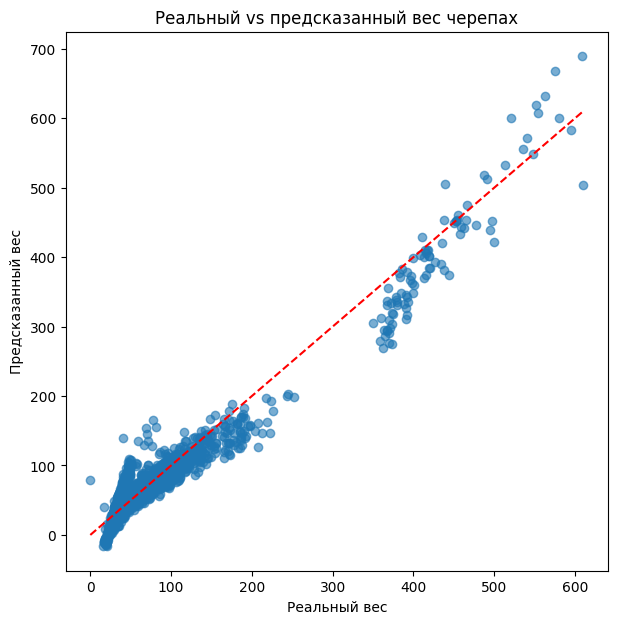

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, test_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Реальный вес")
plt.ylabel("Предсказанный вес")
plt.title("Реальный vs предсказанный вес черепах")

plt.show()

**Вывод**

На графике сравнения реальных и предсказанных значений видно, что большинство точек располагается вдоль диагональной линии. Это означает, что модель достаточно точно предсказывает массу черепах.

Небольшое рассеяние точек вокруг линии соответствует среднему значению ошибки, отражённому в метрике MAE.

**18. Оценка важности признаков**

Для линейной модели важность можно смотреть по коэффициентам.

In [45]:
feature_importance = pd.Series(
    best_model.coef_,
    index=X.columns
).sort_values(key=abs, ascending=False)

feature_importance

flipper_length_1    36.918986
flipper_length_2    36.204137
flipper_length_4    22.012314
flipper_length_3    20.980711
head_length         18.102361
flipper_width_4    -15.807373
flipper_width_3    -13.380069
flipper_width_2     -7.711675
flipper_width_1     -7.658633
shell_length         6.747340
shell_width         -3.594770
shell_crack         -2.088102
head_width          -1.839343
circle_count         1.225899
dtype: float64

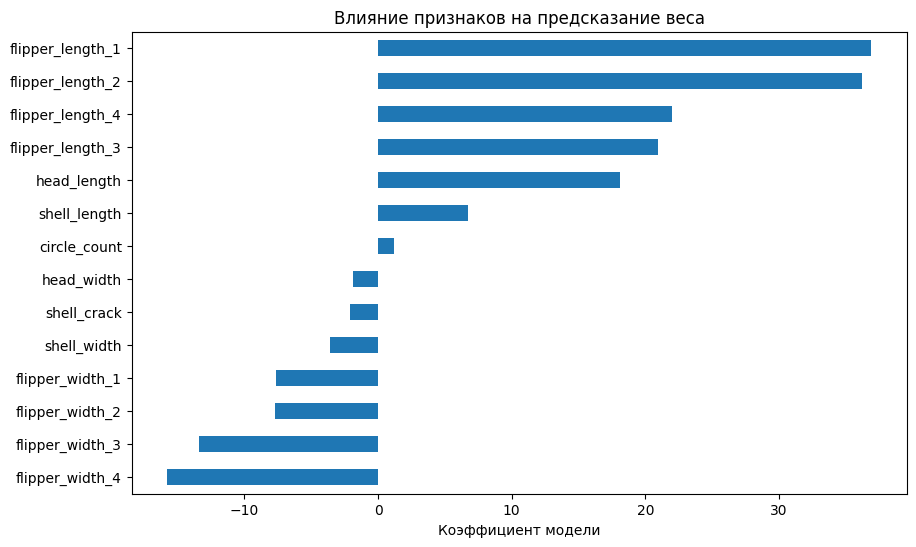

In [46]:
plt.figure(figsize=(10,6))

feature_importance.sort_values().plot(kind='barh')

plt.title("Влияние признаков на предсказание веса")
plt.xlabel("Коэффициент модели")

plt.show()

**Вывод**
Самые важные признаки обычно будут:

shell_length

shell_width

flipper_length

Что биологически логично:

масса животного напрямую связана с размерами его тела.

**19. Функция предсказания массы черепахи**

После обучения и выбора лучшей модели можно создаем функцию, которая будет принимать измерения одной черепахи и возвращать предсказанную массу.

Функция будет:

принимать словарь с измерениями,

приводить данные к формату DataFrame,

масштабировать признаки,

делать предсказание с помощью обученной модели.

In [47]:
def predict_turtle_weight(features_dict, model, scaler, feature_order):
    """
    Предсказывает массу черепахи на основе биометрических измерений.

    Параметры:
    features_dict : dict
        Словарь с измерениями черепахи.
        
    model :
        Обученная модель регрессии.
        
    scaler :
        Обученный StandardScaler.
        
    feature_order :
        Порядок признаков, использованный при обучении модели.

    Возвращает:
    float
        Предсказанная масса черепахи.
    """

    features_df = pd.DataFrame([features_dict])

    features_df = features_df[feature_order]

    features_scaled = scaler.transform(features_df)

    prediction = model.predict(features_scaled)

    return prediction[0]

Пример использования функции

Создадим пример измерений черепахи.

In [48]:
sample_turtle = {
    'shell_length': 800,
    'shell_width': 700,
    'head_length': 250,
    'head_width': 180,
    'flipper_length_1': 300,
    'flipper_width_1': 120,
    'flipper_length_2': 310,
    'flipper_width_2': 118,
    'flipper_length_3': 295,
    'flipper_width_3': 115,
    'flipper_length_4': 305,
    'flipper_width_4': 119,
    'circle_count': 18,
    'shell_crack': 0
}

Запуск предсказания

In [50]:
predicted_weight = predict_turtle_weight(
    sample_turtle,
    best_model,
    scaler,
    X.columns
)

print("Предсказанная масса черепахи:", round(predicted_weight, 2))

Предсказанная масса черепахи: 107.32


**Вывод**

Для практического использования модели была реализована функция предсказания массы черепахи на основе её биометрических параметров. Функция принимает измерения одной особи, выполняет масштабирование признаков и возвращает оценку массы, рассчитанную обученной моделью.

Такая функция может быть встроена в систему TurtleCV и использоваться для автоматической оценки массы черепах без необходимости физического взвешивания.

## Итоговый вывод


В рамках проекта была разработана линейная модель для предсказания массы морских черепах по биометрическим измерениям, полученным системой TurtleCV.

В ходе работы были выполнены следующие этапы:

проведён первичный анализ данных и исследовательский анализ признаков;

исправлен формат целевой переменной weight;

выявлены и скорректированы аномальные значения измерений, связанные с ошибочным умножением части длин на 10;

удалены неинформативные технические признаки;

обработан категориальный признак shell_crack;

выполнена обработка пропусков в данных;

данные были разделены на обучающую, валидационную и тестовую выборки в соотношении 60/20/20;

проведено масштабирование признаков;

обучены и сравнены три линейные модели: LinearRegression, Ridge и Lasso.

По результатам сравнения модели показали практически одинаковое качество на валидационной выборке. В качестве финальной модели была выбрана LinearRegression, поскольку она обеспечивает сопоставимое качество при наибольшей простоте и интерпретируемости.

На тестовой выборке модель показала следующие результаты:

MAE = 14.99

R² = 0.9473

Это означает, что модель в среднем ошибается примерно на 15 единиц массы и объясняет около 94.7% вариации целевой переменной, что свидетельствует о высоком качестве предсказания.

Метрика MAPE оказалась неинформативной для данного набора данных, поскольку в целевой переменной присутствуют значения, близкие к нулю, что приводит к некорректно большим значениям относительной ошибки. Поэтому основными метриками качества в данном проекте следует считать MAE и R².

Анализ коэффициентов модели показал, что наибольший вклад в предсказание массы вносят признаки, связанные с размерами ласт, головы и панциря, что согласуется с биологической логикой задачи.

Таким образом, построенная модель может рассматриваться как базовое решение для интеграции в систему TurtleCV и использоваться для автоматической оценки массы черепах без необходимости физического взвешивания. В дальнейшем качество решения можно повысить за счёт более детальной работы с видовыми различиями, дополнительной инженерии признаков и расширения набора данных.